

Name: Lakhan Singh

Course: Generative AI




# ASSIGNMENT 1
## Understanding Generative and Discriminative Models Using MNIST

### Objective

The objective of this assignment is to understand the difference between
discriminative and generative models using handwritten digit images from
the MNIST dataset.

In this assignment, only the digits 0 and 1 are used.

- Discriminative Model: Logistic Regression
- Generative Model: Autoencoder

## 1. Import Required Libraries

We import the libraries required for loading the MNIST dataset,
building the discriminative model, creating the autoencoder,
calculating accuracy, and visualizing images.

Here we import the tools we need.

numpy → numerical operations
matplotlib → displaying digit images and results
mnist → loading the MNIST dataset
LogisticRegression → our discriminative model
accuracy_score → calculating classification accuracy
tensorflow/keras → building the Autoencoder

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras import layers, Model

## 2. Load the MNIST Dataset

MNIST is a dataset of handwritten digit images from 0 to 9.
Each image has a size of 28 × 28 pixels.

The dataset is divided into training and testing sets.

In [5]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


## 3. Select Only Digits 0 and 1

The assignment requires us to work only with the handwritten
digits 0 and 1.

Therefore, we filter the original MNIST dataset and remove
all images belonging to digits 2 through 9.

In [6]:
train_mask = (y_train == 0) | (y_train == 1)
test_mask = (y_test == 0) | (y_test == 1)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

Training images: (12665, 28, 28)
Testing images: (2115, 28, 28)


## 4. Visualize Sample Images

Before training the models, we visualize some examples
from the filtered dataset.

This helps us understand what the model will learn.

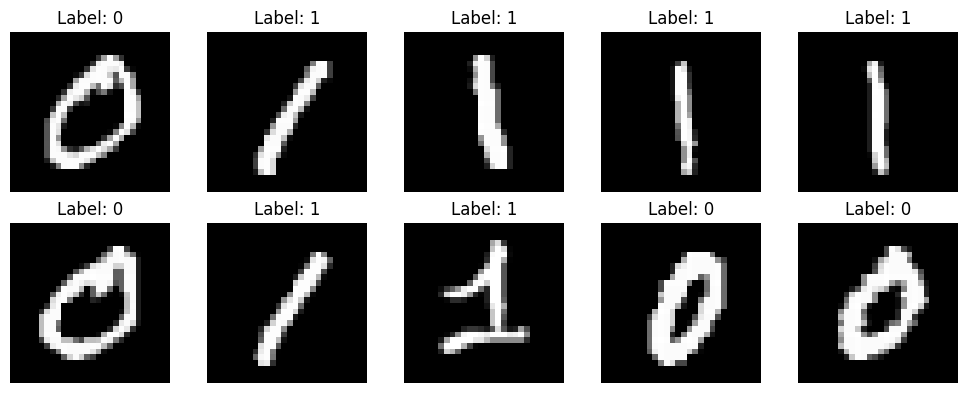

In [7]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Data Preprocessing for the Discriminative Model

MNIST images are 28 × 28 pixels.

Logistic Regression expects each image to be represented
as a one-dimensional feature vector.

Therefore, each 28 × 28 image is flattened into 784 features.

Pixel values are also normalized from the range 0–255 to 0–1.

In [8]:
X_train_lr = X_train.reshape(X_train.shape[0], -1)
X_test_lr = X_test.reshape(X_test.shape[0], -1)

In [9]:
X_train_lr = X_train_lr / 255.0
X_test_lr = X_test_lr / 255.0

In [26]:
print("Training shape:", X_train_lr.shape)
print("Testing shape:", X_test_lr.shape)

Training shape: (12665, 784)
Testing shape: (2115, 784)


## 6. Discriminative Model — Logistic Regression

A discriminative model learns how to distinguish between
different classes.

In this assignment, Logistic Regression learns the patterns
that separate handwritten 0s from handwritten 1s.

Its goal is to predict whether a new image belongs to class 0 or class 1.

In [10]:
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train_lr, y_train)

LogisticRegression(max_iter=1000)

In [11]:
y_pred = model_lr.predict(X_test_lr)

## 7. Evaluate the Discriminative Model

After training, the model is tested on images that it
has not seen during training.

We calculate the classification accuracy to measure
how correctly it identifies digits 0 and 1.

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Discriminative Model Accuracy: {accuracy * 100:.2f}%")

Discriminative Model Accuracy: 99.95%


## 8. Classification Report

The classification report provides additional performance
metrics for the discriminative model.

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115



## 9. Visualizing Predictions

We compare the actual labels of test images with the
predictions made by the discriminative model.

This allows us to visually check whether the model
correctly classifies handwritten 0s and 1s.

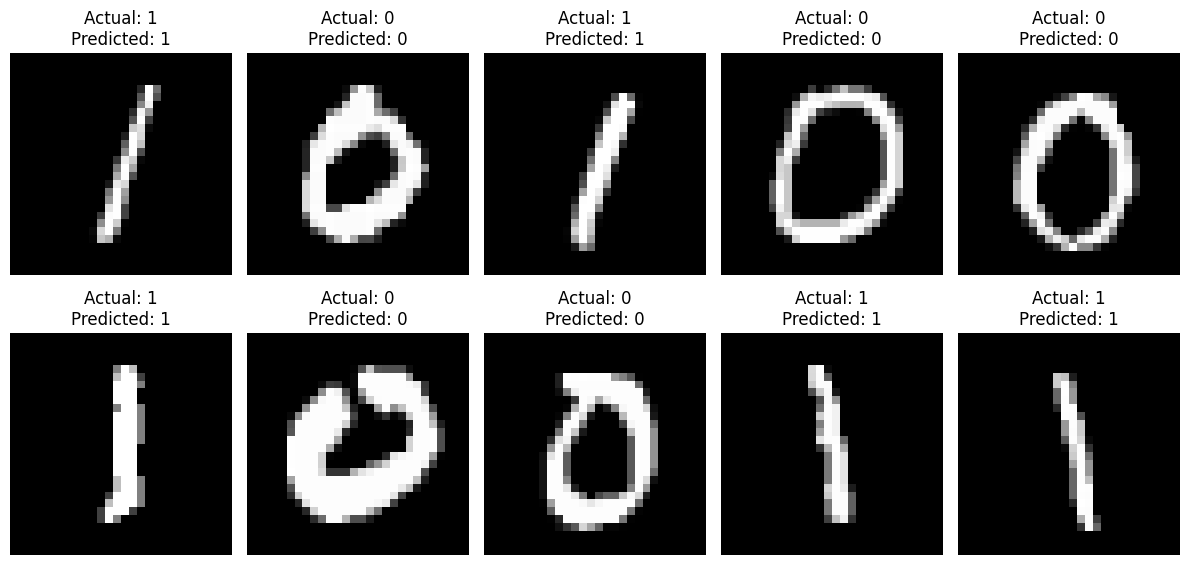

In [13]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Actual: {y_test[i]}\nPredicted: {y_pred[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 10. Prepare Data for the Generative Model

The generative model used in this assignment is a basic Autoencoder.

Unlike the discriminative model, the Autoencoder does not need
the digit labels for training.

It learns directly from the images and attempts to reconstruct
them after compressing their information into a smaller representation.

In [14]:
X_train_ae = X_train.astype("float32") / 255.0
X_test_ae = X_test.astype("float32") / 255.0

In [15]:
X_train_ae = X_train_ae.reshape(-1, 784)
X_test_ae = X_test_ae.reshape(-1, 784)

In [28]:
print("Autoencoder training shape:", X_train_ae.shape)
print("Autoencoder testing shape:", X_test_ae.shape)

Autoencoder training shape: (12665, 784)
Autoencoder testing shape: (2115, 784)


## 11. Build the Autoencoder

An Autoencoder contains two main parts:

1. Encoder — compresses the input image into a smaller latent representation.
2. Decoder — reconstructs the image from the latent representation.

The model therefore learns important patterns present in the handwritten digits.

In [16]:
input_img = layers.Input(shape=(784,))

# Encoder
encoded = layers.Dense(128, activation="relu")(input_img)
encoded = layers.Dense(32, activation="relu")(encoded)

# Decoder
decoded = layers.Dense(128, activation="relu")(encoded)
decoded = layers.Dense(784, activation="sigmoid")(decoded)

autoencoder = Model(input_img, decoded)

autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

## 12. Train the Autoencoder

The Autoencoder is trained by giving it an image as both
the input and the target.

The objective is to reconstruct the original image as accurately
as possible.

In [17]:
history = autoencoder.fit(
    X_train_ae,
    X_train_ae,
    epochs=10,
    batch_size=128,
    validation_data=(X_test_ae, X_test_ae),
    verbose=1
)

Epoch 1/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.2527 - val_loss: 0.1403
Epoch 2/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1264 - val_loss: 0.1142
Epoch 3/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.1112 - val_loss: 0.1035
Epoch 4/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1001 - val_loss: 0.0931
Epoch 5/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0920 - val_loss: 0.0873
Epoch 6/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0869 - val_loss: 0.0837
Epoch 7/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0838 - val_loss: 0.0812
Epoch 8/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0813 - val_loss: 0.0792
Epoch 9/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0791 - val_loss: 0.0769
Epoch 10/10
99/99 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0774 - val_loss: 0.0757


## 13. Training Loss

We visualize the training and validation loss to observe
how the Autoencoder learns during training.

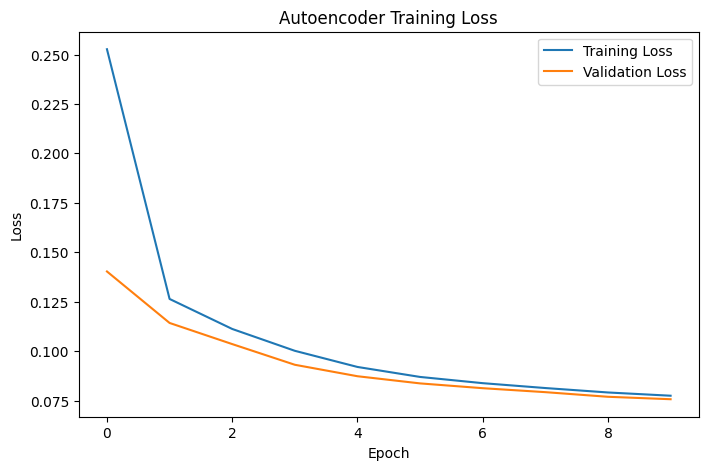

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.show()

## 14. Reconstruct Test Images

After training, we pass test images through the Autoencoder.

The output is the reconstructed version of each image.

We compare the original and reconstructed images to see
what the Autoencoder has learned.

In [30]:
reconstructed = autoencoder.predict(X_test_ae[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


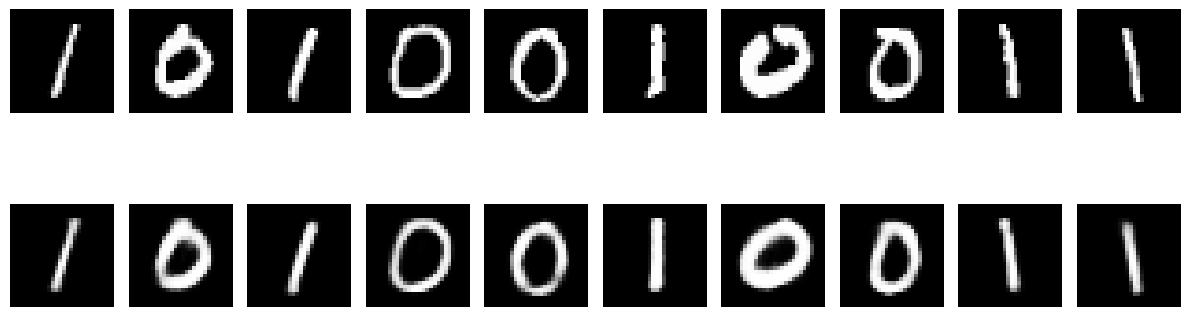

In [32]:
plt.figure(figsize=(12, 5))

for i in range(10):
    # Original
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test_ae[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    # Reconstructed
    plt.subplot(2, 10, i + 11)
    plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 15. Create Encoder and Decoder Models

The trained Autoencoder contains an encoder and decoder.

We separate them so that we can:

1. Convert real images into latent representations.
2. Modify/sample latent representations.
3. Decode them into new digit-like images.

In [20]:
encoder = Model(input_img, encoded)

latent_input = layers.Input(shape=(32,))
decoder_layer1 = autoencoder.layers[-2]
decoder_layer2 = autoencoder.layers[-1]

decoder = Model(
    latent_input,
    decoder_layer2(decoder_layer1(latent_input))
)

## 16. Generate New Digit-like Images

To demonstrate generation, we obtain latent representations
from real MNIST images and add a small amount of random variation.

The modified latent representations are then passed through
the decoder to produce new digit-like images.

These images are not copied directly from the original dataset;
they are produced by the decoder from modified latent representations.

In [21]:
latent_vectors = encoder.predict(X_train_ae[:1000])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [22]:
noise = np.random.normal(
    0,
    0.5,
    latent_vectors[:10].shape
)

new_latent_vectors = latent_vectors[:10] + noise

In [23]:
generated_images = decoder.predict(new_latent_vectors)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


## 17. Generated Digit Images

The following images are generated by passing modified
latent representations through the trained decoder.

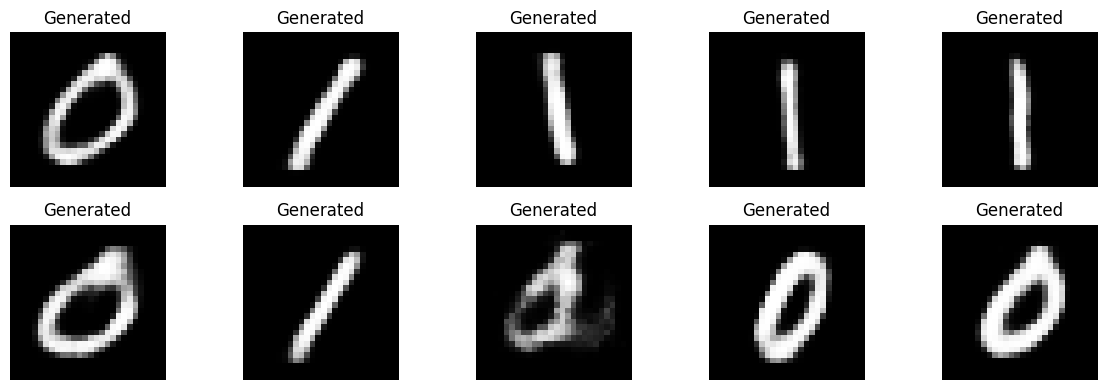

In [24]:
plt.figure(figsize=(12, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 18. Visual Comparison

This section compares:

1. Real MNIST images
2. Discriminative model predictions
3. Generated images from the Autoencoder

The comparison demonstrates the difference between classification
and generation.

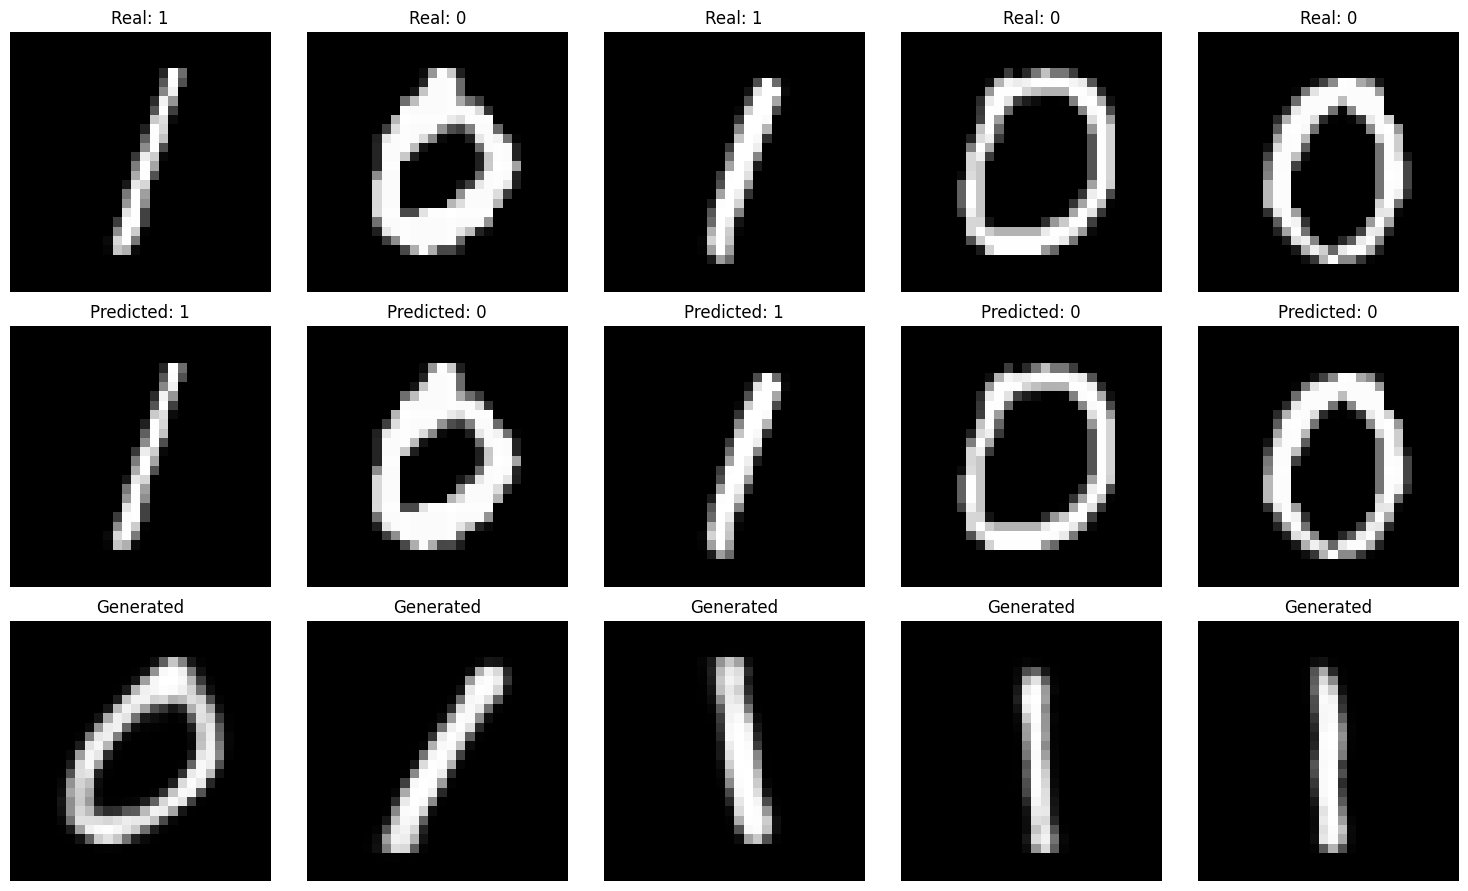

In [25]:
plt.figure(figsize=(15, 9))

for i in range(5):

    # Real
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Real: {y_test[i]}")
    plt.axis("off")

    # Prediction
    plt.subplot(3, 5, i + 6)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Predicted: {y_pred[i]}")
    plt.axis("off")

    # Generated
    plt.subplot(3, 5, i + 11)
    plt.imshow(generated_images[i].reshape(28, 28), cmap="gray")
    plt.title("Generated")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 19. Discriminative vs Generative Models

### Discriminative Model

The Logistic Regression model learns how to distinguish
between the two classes, 0 and 1. It learns a decision boundary
that can be used to classify new images.

### Generative Model

The Autoencoder learns important patterns and representations
from the digit images. It uses an encoder to learn a latent
representation and a decoder to reconstruct or produce
digit-like images.

### Key Difference

The discriminative model focuses on predicting the correct class,
while the generative model focuses on learning the structure
and patterns of the input data.

## Conclusion

The discriminative model learned the differences between handwritten
0 and 1 images and used these patterns to classify new images.
The generative model learned the visual patterns and structure
present in the digit images. The Autoencoder compressed the images
into a smaller latent representation and used it to reconstruct
and generate digit-like examples. The main difference is that the
discriminative model focuses on prediction, while the generative
model focuses on learning data patterns and producing new examples.

This assignment demonstrated the difference between discriminative
and generative learning using MNIST digits 0 and 1.

Logistic Regression successfully learned to classify the two digits
and provided a measurable classification accuracy. The Autoencoder
learned compressed representations of the digit images and used
these representations to reconstruct and generate digit-like images.

Therefore, the discriminative model learns a decision boundary,
while the generative model learns patterns and representations
of the data that can be used to produce new examples.